In [ ]:
# Emotion Dynamics & Engagement Correlation Analysis
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- CONFIG ---
EMOTION_FILE = Path("../data/processed/all_emotions.csv")
METADATA_FILE = Path("../data/raw/metadata.csv")
OUTPUT_STATS = Path("../data/processed/video_emotion_stats.csv")

# --- Load data ---
emotion_df = pd.read_csv(EMOTION_FILE)
meta_df = pd.read_csv(METADATA_FILE)

In [3]:
# --- Per-Video Emotion Stats ---
emotion_cols = [col for col in emotion_df.columns if col not in ['start', 'end', 'text', 'clean_text', 'time', 'video_id']]

video_stats = emotion_df.groupby("video_id")[emotion_cols].agg(['mean', 'std', 'max']).reset_index()
video_stats.columns = ['_'.join(col).strip('_') for col in video_stats.columns.values]  # flatten MultiIndex

# --- Merge with engagement & channel metadata ---
meta_cols = [
    'videoId', 'viewCount', 'likeCount', 'commentCount', 'channelId',
    'channelViewCount', 'subscriberCount', 'channelVideoCount', 'duration_sec'
]
meta_df = meta_df[meta_cols].drop_duplicates(subset='videoId')
meta_df.rename(columns={'videoId': 'video_id'}, inplace=True)

combined_df = pd.merge(video_stats, meta_df, on='video_id', how='inner')

# --- Compute engagement ratios ---
combined_df['like_ratio'] = combined_df['likeCount'] / combined_df['viewCount'].replace(0, np.nan)
combined_df['comment_ratio'] = combined_df['commentCount'] / combined_df['viewCount'].replace(0, np.nan)
combined_df['views_per_video'] = combined_df['viewCount'] / combined_df['channelVideoCount'].replace(0, np.nan)

In [4]:
# --- Save output ---
combined_df.to_csv(OUTPUT_STATS, index=False)

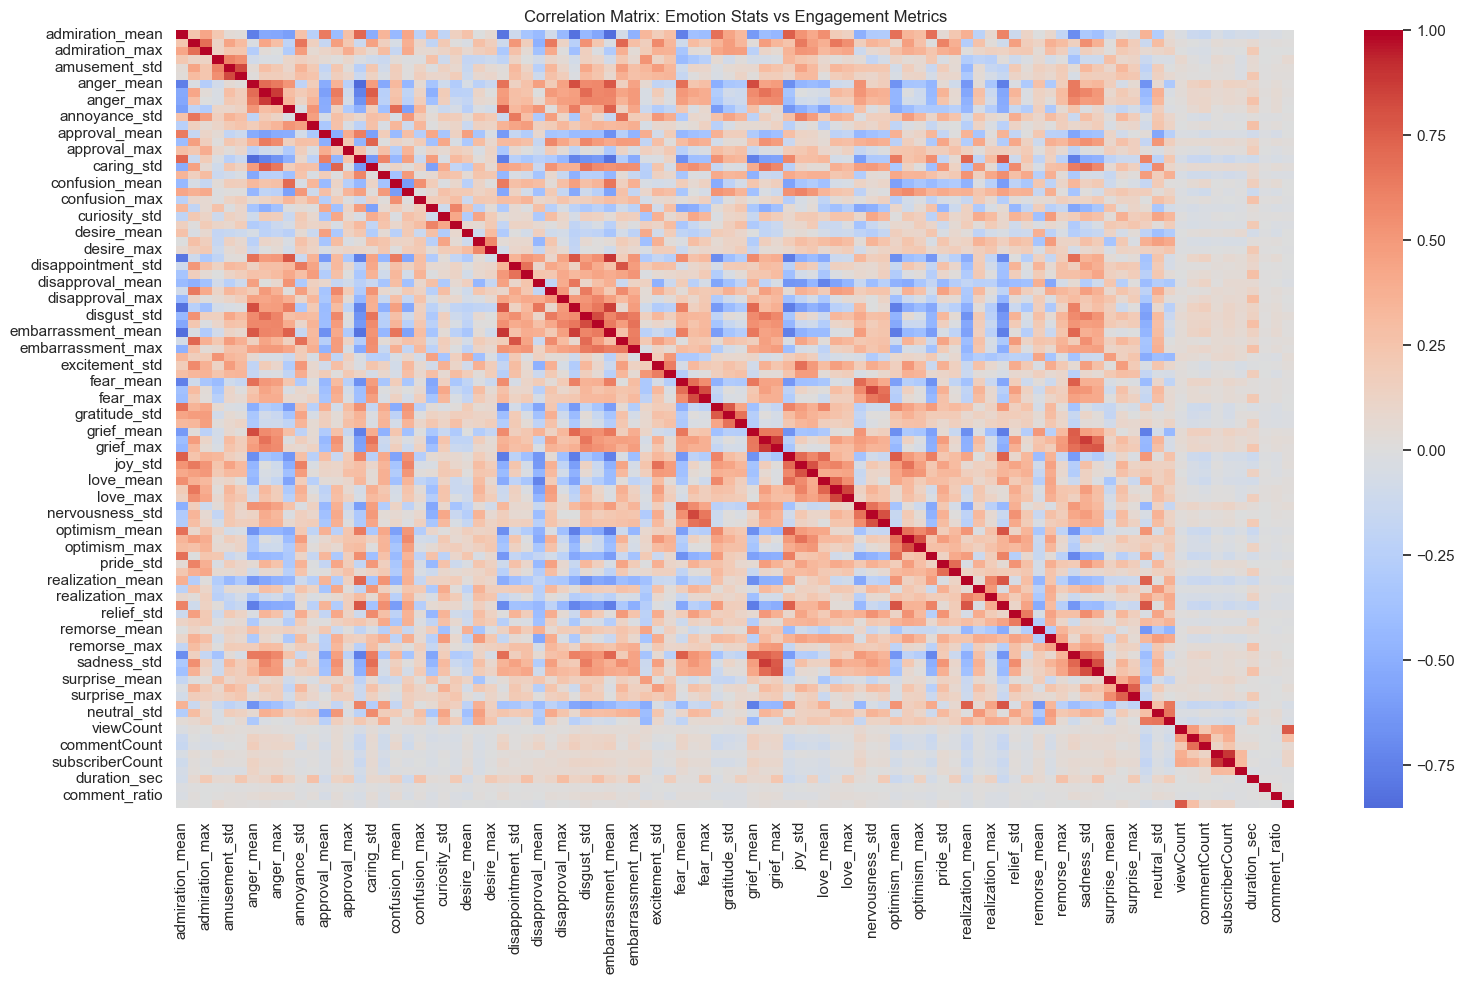

In [5]:
# --- Visualization ---
sns.set(style="whitegrid")

# Correlation heatmap
plt.figure(figsize=(16, 10))
corr = combined_df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=False, center=0)
plt.title("Correlation Matrix: Emotion Stats vs Engagement Metrics")
plt.tight_layout()
plt.show()

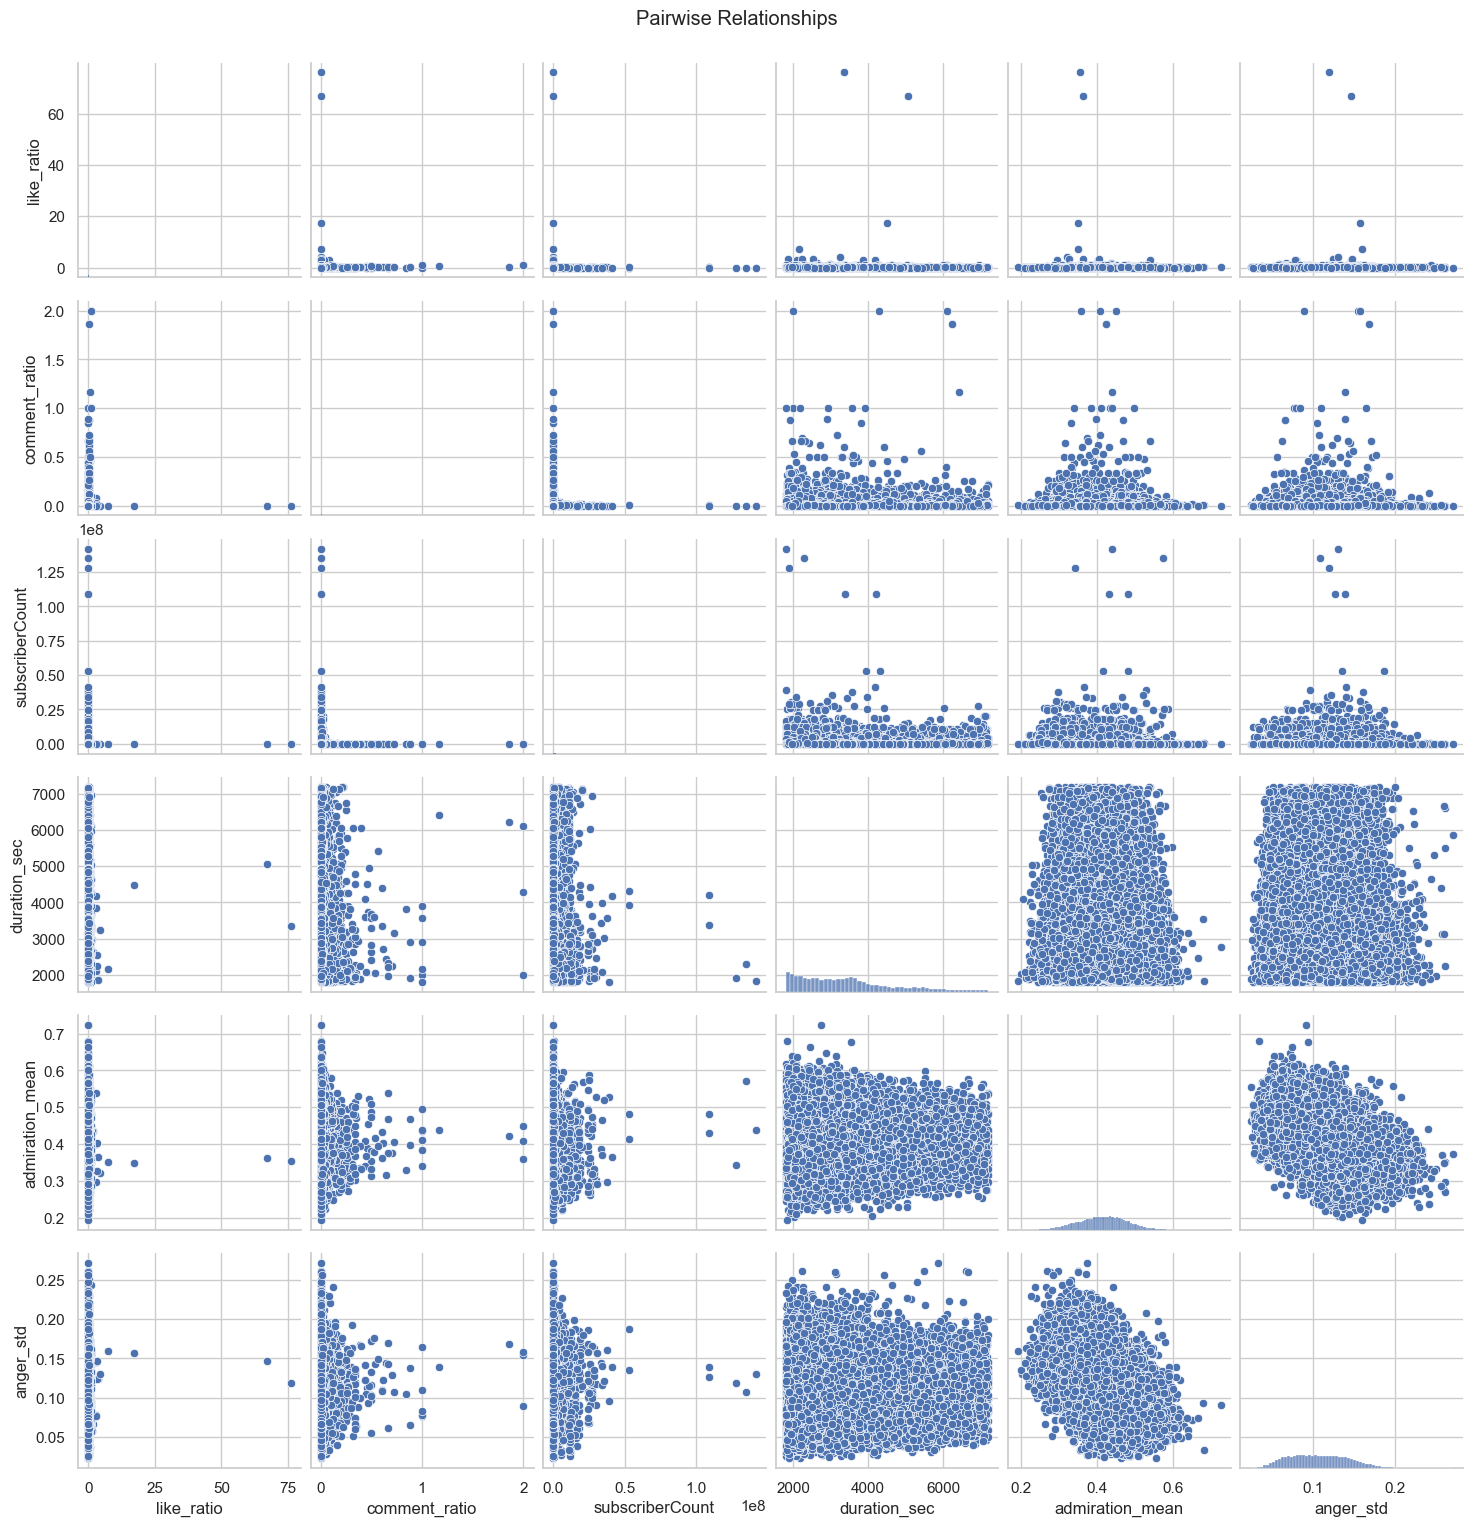

In [6]:
# Pairplot for selected metrics
selected_metrics = ['like_ratio', 'comment_ratio', 'subscriberCount', 'duration_sec']
selected_emotions = [col for col in combined_df.columns if col.startswith('admiration_mean') or col.startswith('anger_std')]
sns.pairplot(combined_df[selected_metrics + selected_emotions].dropna())
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()